In [1]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.6 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [6]:
DATASET_PATH = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [9]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(train_dataset.classes)

['NORMAL', 'PNEUMONIA']


In [10]:
class PneumoniaCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*14*14,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,2)
        )

    def forward(self,x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [11]:
model = PneumoniaCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [13]:
from tqdm.auto import tqdm

epochs = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(epochs):

    print(f"\nEpoch [{epoch+1}/{epochs}]")

    # ================= TRAIN =================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    train_bar = tqdm(
        train_loader,
        desc="Training",
        leave=False
    )

    for batch_idx, (images, labels) in enumerate(train_bar):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        current_acc = 100.0 * correct / total

        train_bar.set_postfix(
            Loss=f"{running_loss/(batch_idx+1):.4f}",
            Acc=f"{current_acc:.2f}%"
        )

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ================= VALIDATION =================
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_bar = tqdm(
        val_loader,
        desc="Validation",
        leave=False
    )

    with torch.no_grad():

        for batch_idx, (images, labels) in enumerate(val_bar):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            current_acc = 100.0 * correct / total

            val_bar.set_postfix(
                Loss=f"{val_loss/(batch_idx+1):.4f}",
                Acc=f"{current_acc:.2f}%"
            )

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )


Epoch [1/10]


Training:   0%|          | 0/163 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch [1/10] Train Loss: 0.3776 | Train Acc: 82.42% | Val Loss: 1.3169 | Val Acc: 50.00%

Epoch [2/10]


Training:   0%|          | 0/163 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch [9/10] Train Loss: 0.0960 | Train Acc: 96.51% | Val Loss: 0.2819 | Val Acc: 93.75%

Epoch [10/10]


Training:   0%|          | 0/163 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch [10/10] Train Loss: 0.0904 | Train Acc: 96.51% | Val Loss: 0.4939 | Val Acc: 68.75%


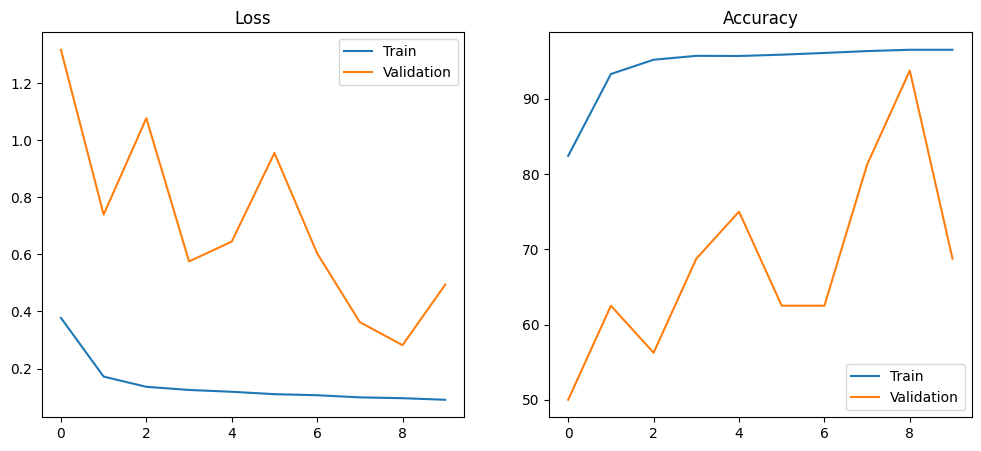

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses,label='Train')
plt.plot(val_losses,label='Validation')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs,label='Train')
plt.plot(val_accs,label='Validation')
plt.title("Accuracy")
plt.legend()

plt.show()

In [15]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

In [16]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

      NORMAL       0.96      0.50      0.65       234
   PNEUMONIA       0.77      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.74      0.76       624
weighted avg       0.84      0.80      0.78       624



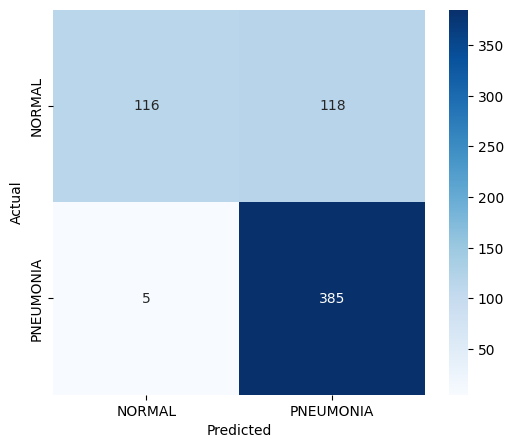

In [17]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

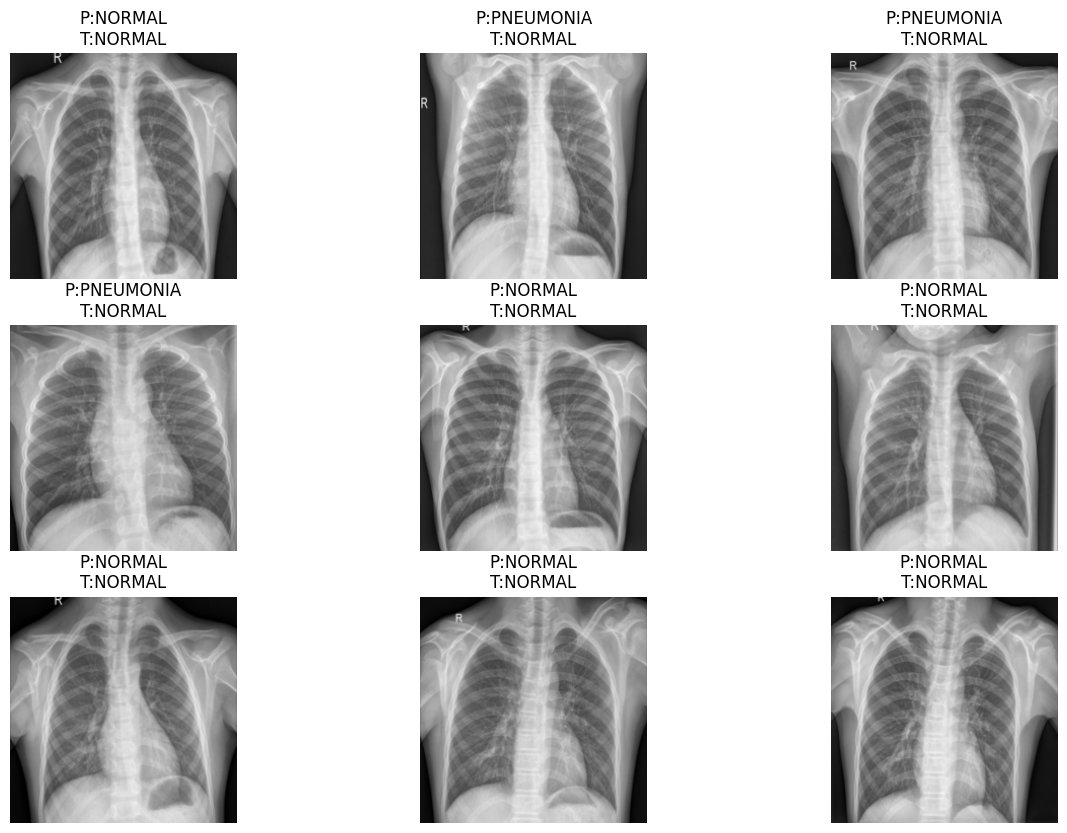

In [18]:
images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():

    outputs = model(images.to(device))
    preds = outputs.argmax(1).cpu()

plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    img = images[i].permute(1,2,0)

    plt.imshow(img)

    plt.title(
        f"P:{test_dataset.classes[preds[i]]}\nT:{test_dataset.classes[labels[i]]}"
    )

    plt.axis("off")

plt.show()

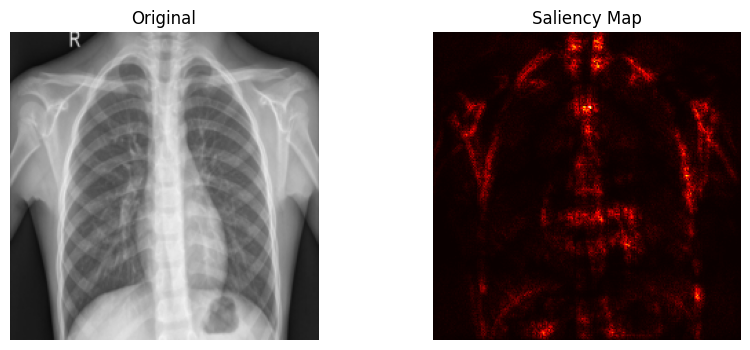

In [19]:
image, label = test_dataset[0]

input_img = image.unsqueeze(0).to(device)

input_img.requires_grad_()

output = model(input_img)

pred_class = output.argmax()

model.zero_grad()

output[0,pred_class].backward()

saliency = input_img.grad.abs()

saliency,_ = torch.max(
    saliency,
    dim=1
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    saliency.squeeze().cpu(),
    cmap='hot'
)
plt.title("Saliency Map")
plt.axis("off")

plt.show()

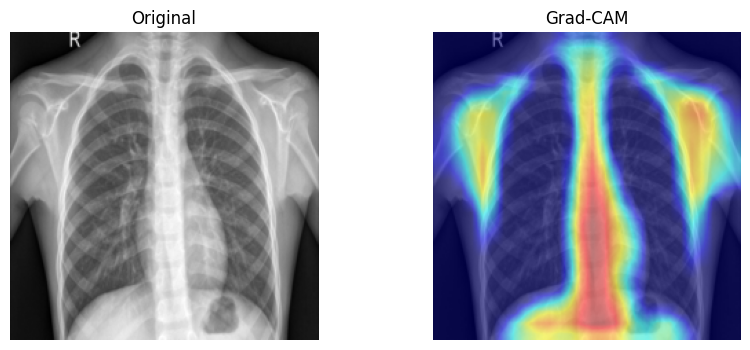

In [20]:
target_layers = [model.features[9]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

target = [ClassifierOutputTarget(label)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=target
)[0]

rgb_img = image.permute(
    1,
    2,
    0
).numpy()

rgb_img = (
    rgb_img-rgb_img.min()
)/(
    rgb_img.max()-rgb_img.min()
)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

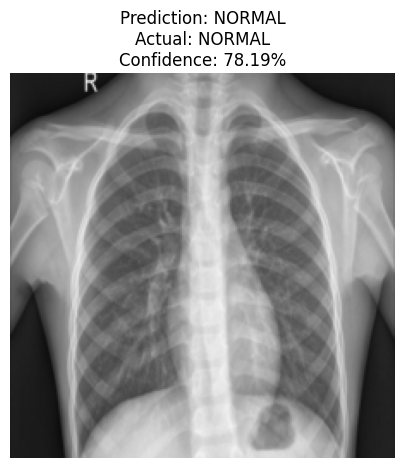

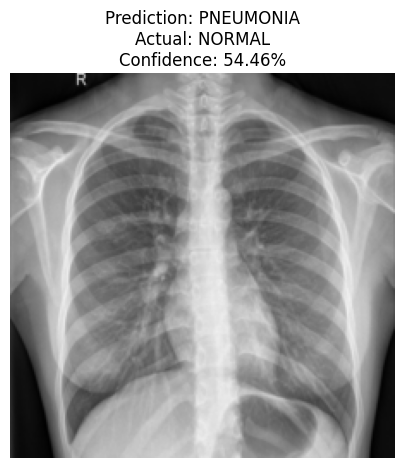

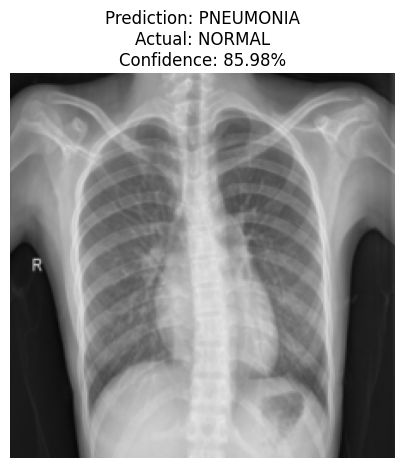

In [22]:
import torch.nn.functional as F

class_names = test_dataset.classes

model.eval()

for idx in [0, 10, 20]:

    image, true_label = test_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)

    pred_class = torch.argmax(probs).item()
    confidence = probs[0][pred_class].item() * 100

    plt.figure(figsize=(5,5))
    plt.imshow(image.permute(1,2,0))
    plt.axis("off")

    plt.title(
        f"Prediction: {class_names[pred_class]}\n"
        f"Actual: {class_names[true_label]}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.show()